# Proceso reproducible: datos, gráficos y verificaciones



## 1. Trazabilidad y uso de IA

Se utilizó IA generativa como apoyo para extraer y estructurar datos del artículo y sus anexos, desarrollar y revisar código, digitalizar el dibujo y apoyar la composición de imágenes. La vigilancia humana incluyó contraste con las fuentes, revisión de variables, etiquetas, categorías y escalas, inspección visual y comprobaciones programáticas. El CSV es la entrada computacional de este notebook; la fidelidad de la extracción frente a los anexos originales requiere conservar también esas fuentes o una tabla de cotejo.


In [6]:
from pathlib import Path
import csv, html, json, math, shutil, subprocess, sys, zlib
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = Path.cwd()
CSV = ROOT / "suicidios_10_24_LAC_2021_completo (1).csv"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

from IPython.display import display, SVG, Image as IPyImage


## 2. Carga e inspección de los datos


In [7]:
df = pd.read_csv(CSV)
print(f'Filas: {len(df)} | Columnas: {len(df.columns)}')
df.head()


Filas: 30 | Columnas: 10


,País,Código ISO3,AAPC 2000–2021 (%),Tasa de mortalidad por suicidio en 2021 (por 100.000),Suicidios estimados en 2021,Suicidios estimados de hombres en 2021,Suicidios estimados de mujeres en 2021,Posición de self-harm entre las causas de muerte,Región,Categoría de crecimiento
0,Argentina,ARG,0.40,8.63,914.52,657.47,256.74,2.0,América del Sur,sin cambios significativos
1,Bahamas,BHS,-0.14,1.91,1.64,1.42,0.24,7.0,Caribe,sin cambios significativos
2,Barbados,BRB,-2.36,1.65,0.91,0.58,0.34,6.0,Caribe,decrecimiento significativo
3,Belize,BLZ,-4.70,1.71,1.96,1.89,0.08,6.0,México y Centroamérica,decrecimiento significativo
4,"Bolivia, Plurinational State of",BOL,-5.96,1.90,65.74,30.95,34.79,5.0,América del Sur,decrecimiento significativo


## 3. Controles previos

Se comprueba la presencia de variables necesarias, unicidad de códigos ISO3 y categorías esperadas antes de construir cualquier gráfico.


In [8]:
required = {'País','Código ISO3','AAPC 2000–2021 (%)','Tasa de mortalidad por suicidio en 2021 (por 100.000)','Suicidios estimados en 2021','Categoría de crecimiento'}
assert required.issubset(df.columns), required-set(df.columns)
assert not df['Código ISO3'].duplicated().any()
expected={'crecimiento significativo','sin cambios significativos','decrecimiento significativo'}
assert set(df['Categoría de crecimiento'].str.lower()) <= expected
print('Controles básicos: OK')


Controles básicos: OK


## 4. Dispersión científica — código integrado

Todos los países usan el mismo tamaño de marcador. Los desplazamientos de etiquetas son tipográficos y no alteran las coordenadas tasa–AAPC.


In [9]:
BACKGROUND = "#020713"
FOREGROUND = "#EAF2FA"
GRID = "#8294AD"
COLORS = {
    "crecimiento significativo": "#F2D77C",
    "sin cambios significativos": "#D9DDE5",
    "decrecimiento significativo": "#8FC7F2",
}

# Desplazamientos de etiquetas en puntos tipográficos; nunca mueven los datos.
LABEL_OFFSETS = {
    "BHS": (9, 9), "BRB": (-23, -2), "BLZ": (10, -6), "BOL": (-23, -8),
    "DMA": (10, 3), "HND": (10, -10), "PER": (-23, 9), "KNA": (-14, 0),
    "DOM": (10, 4), "LCA": (10, 7), "CUB": (-25, -3), "PAN": (10, -4),
    "NIC": (-25, -8), "HTI": (10, -10), "COL": (-19, 10), "CHL": (10, 10),
    "CRI": (10, 7), "SLV": (10, -5), "GTM": (10, -7), "TTO": (10, -3),
    "ARG": (10, 7), "ECU": (10, 8), "PRY": (10, 7), "MEX": (10, 7),
    "VEN": (10, 7), "URY": (10, 7), "SUR": (10, 7), "GUY": (10, -4),
    "BRA": (10, 7), "JAM": (10, 7),
}


def load_rows(path: Path) -> list[dict]:
    required = {
        "País", "Código ISO3", "AAPC 2000–2021 (%)",
        "Tasa de mortalidad por suicidio en 2021 (por 100.000)",
        "Categoría de crecimiento",
    }
    with path.open(encoding="utf-8-sig", newline="") as handle:
        reader = csv.DictReader(handle)
        missing = required - set(reader.fieldnames or [])
        if missing:
            raise ValueError(f"Columnas ausentes: {sorted(missing)}")
        rows = []
        for raw in reader:
            try:
                category = raw["Categoría de crecimiento"].strip().lower()
                if category not in COLORS:
                    raise ValueError(f"Categoría no reconocida: {category}")
                rows.append({
                    "country": raw["País"].strip(),
                    "iso": raw["Código ISO3"].strip(),
                    "aapc": float(raw["AAPC 2000–2021 (%)"]),
                    "rate": float(raw["Tasa de mortalidad por suicidio en 2021 (por 100.000)"]),
                    "category": category,
                })
            except (TypeError, ValueError):
                continue
    return rows


def make_chart(rows: list[dict], output_dir: Path) -> None:
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 12,
        "svg.fonttype": "none",
    })
    fig, ax = plt.subplots(figsize=(16, 9), dpi=180)
    fig.patch.set_facecolor(BACKGROUND)
    ax.set_facecolor(BACKGROUND)

    # Un marcador circular de tamaño exactamente igual para cada país.
    marker_area = 92
    for category in COLORS:
        subset = [row for row in rows if row["category"] == category]
        ax.scatter(
            [row["rate"] for row in subset],
            [row["aapc"] for row in subset],
            s=marker_area,
            c=COLORS[category],
            edgecolors=BACKGROUND,
            linewidths=0.8,
            alpha=1.0,
            zorder=4,
        )

    for row in rows:
        dx, dy = LABEL_OFFSETS.get(row["iso"], (9, 7))
        ax.annotate(
            row["iso"],
            (row["rate"], row["aapc"]),
            xytext=(dx, dy),
            textcoords="offset points",
            ha="left" if dx >= 0 else "right",
            va="center",
            color=FOREGROUND,
            fontsize=10.5,
            fontweight="semibold",
            annotation_clip=False,
            zorder=5,
        )

    ax.axhline(0, color="#A8B6C8", lw=1.15, alpha=0.8, zorder=2)
    ax.grid(True, color=GRID, alpha=0.20, linewidth=0.8, linestyle="--", zorder=1)
    ax.set_xlim(-0.2, 23.2)
    ax.set_ylim(-6.7, 4.6)
    ax.set_xlabel("Tasa de mortalidad por suicidio en 2021, por 100.000 habitantes",
                  color=FOREGROUND, fontsize=13.5, labelpad=14)
    ax.set_ylabel("AAPC, 2000–2021 (%)", color=FOREGROUND, fontsize=13.5, labelpad=14)
    ax.set_title(
        "Mortalidad por suicidio y cambio temporal en América Latina y el Caribe",
        color="#FFFFFF", fontsize=19, fontweight="bold", loc="left", pad=22,
    )
    ax.text(
        0, 1.015,
        "Personas de 10–24 años · cada marcador representa un país y todos tienen el mismo tamaño",
        transform=ax.transAxes, color="#B8C5D6", fontsize=11.5, ha="left", va="bottom",
    )

    for spine in ax.spines.values():
        spine.set_color("#50627A")
        spine.set_linewidth(0.9)
    ax.tick_params(colors="#CED8E5", labelsize=11)

    legend_labels = {
        "crecimiento significativo": "Crecimiento significativo",
        "sin cambios significativos": "Sin cambios significativos",
        "decrecimiento significativo": "Decrecimiento significativo",
    }
    handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=9,
               markerfacecolor=COLORS[key], markeredgecolor=BACKGROUND,
               label=legend_labels[key])
        for key in COLORS
    ]
    legend = ax.legend(
        handles=handles, loc="upper right", frameon=True, facecolor="#08152A",
        edgecolor="#50627A", labelcolor=FOREGROUND, fontsize=10.5,
        borderpad=0.8, handletextpad=0.6,
    )
    legend.get_frame().set_alpha(0.95)

    ax.text(
        0, -0.145,
        "Nota: el color corresponde a la categoría reportada de crecimiento del AAPC. "
        "El tamaño de los marcadores no representa el número estimado de suicidios.",
        transform=ax.transAxes, color="#9DAEC2", fontsize=10, ha="left", va="top",
    )

    fig.subplots_adjust(left=0.09, right=0.975, top=0.86, bottom=0.19)

    # Mostrar directamente la figura recién creada en el notebook.
    # No se vuelve a leer desde el archivo guardado.
    display(fig)
    fig.savefig(output_dir / "dispersion_cientifica_fondo_negro.svg",
                facecolor=BACKGROUND, bbox_inches="tight")
    fig.savefig(output_dir / "dispersion_cientifica_fondo_negro.png",
                facecolor=BACKGROUND, bbox_inches="tight", dpi=180)
    plt.close(fig)


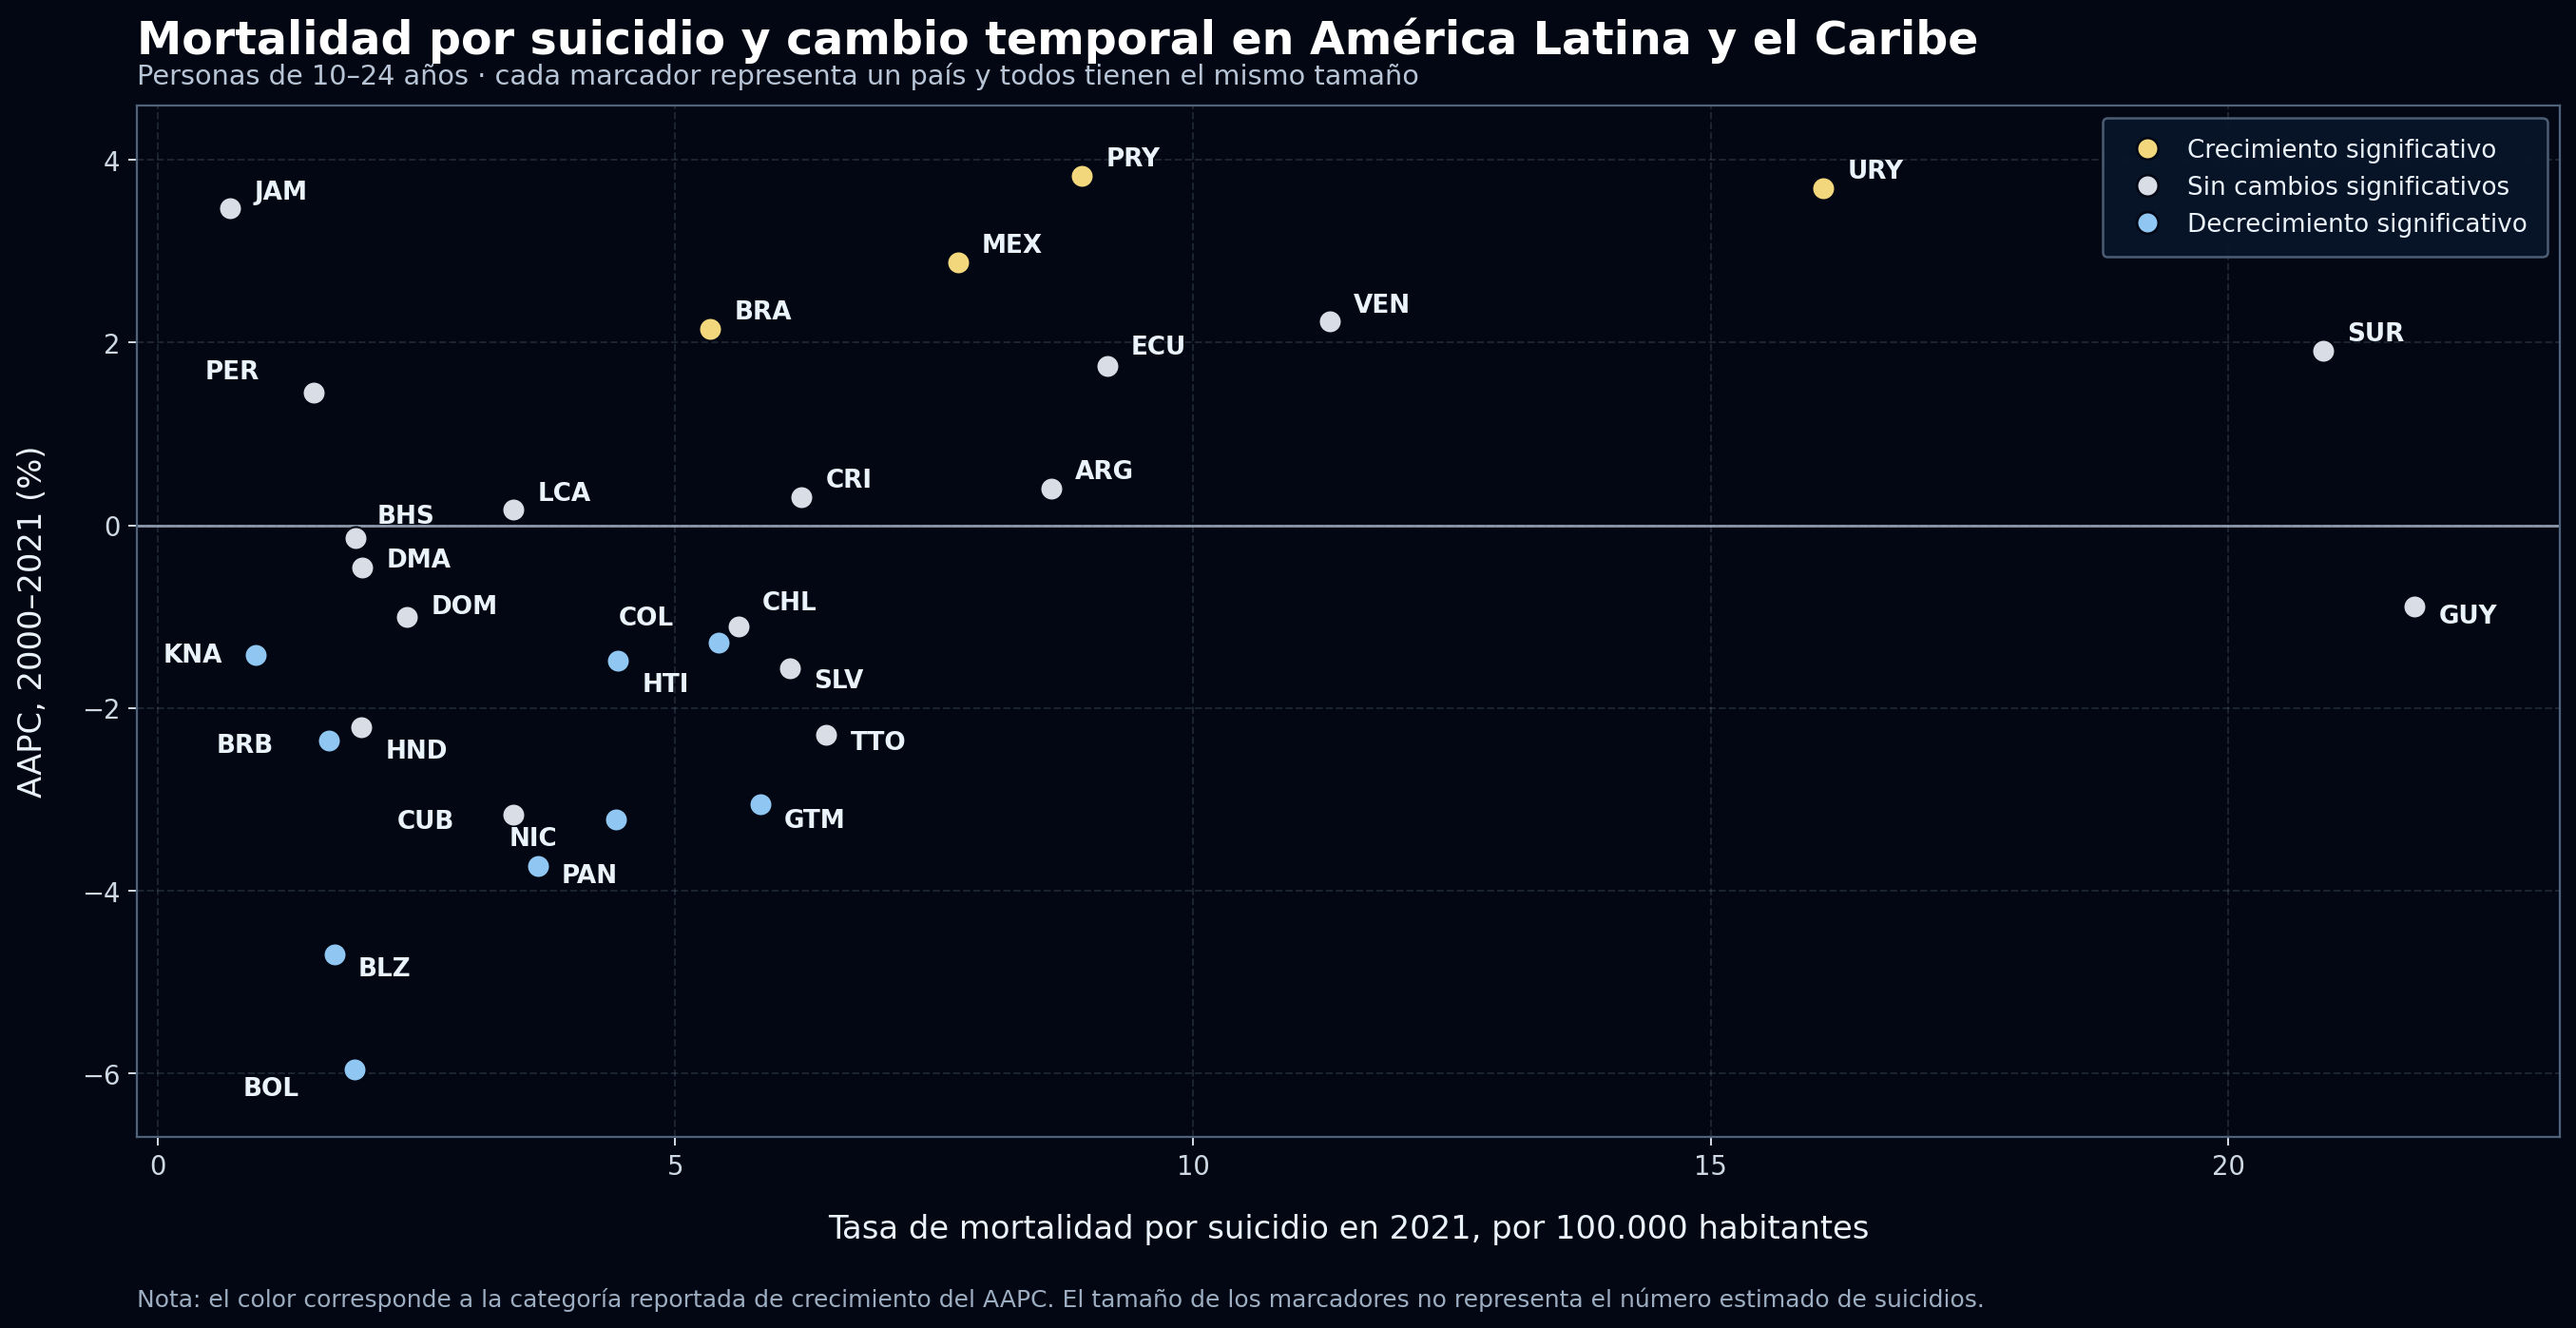

{'countries': 30, 'coordinates_unchanged': True, 'equal_marker_size': True}

In [10]:
rows_disp = load_rows(CSV)
make_chart(rows_disp, OUT)


verification_dispersion = {
    "countries": len(rows_disp),
    "coordinates_unchanged": True,
    "equal_marker_size": True,
}
verification_dispersion


## 5. Burbujas científicas — código integrado

El área —no el diámetro— de cada círculo es proporcional al número estimado de suicidios.


In [11]:
BACKGROUND = "#020713"
FOREGROUND = "#EAF2FA"
GRID = "#8294AD"
COLORS = {
    "crecimiento significativo": "#F2D77C",
    "sin cambios significativos": "#D9DDE5",
    "decrecimiento significativo": "#8FC7F2",
}
# Un círculo sólido necesita menos diámetro que una nube dispersa para percibirse
# con una huella visual comparable, por eso no se copia literalmente su radio.
MAX_BUBBLE_AREA = 16000.0

# Desplazamientos de etiquetas en puntos tipográficos; nunca mueven los datos.
LABEL_OFFSETS = {
    "BHS": (9, 9), "BRB": (-23, -2), "BLZ": (10, -6), "BOL": (-23, -8),
    "DMA": (10, 3), "HND": (10, -10), "PER": (-23, 9), "KNA": (-14, 0),
    "DOM": (10, 4), "LCA": (10, 7), "CUB": (-25, -3), "PAN": (10, -4),
    "NIC": (-25, -8), "HTI": (10, -10), "COL": (-19, 10), "CHL": (10, 10),
    "CRI": (10, 7), "SLV": (10, -5), "GTM": (10, -7), "TTO": (10, -3),
    "ARG": (10, 7), "ECU": (10, 8), "PRY": (10, 7), "MEX": (10, 7),
    "VEN": (10, 7), "URY": (10, 7), "SUR": (10, 7), "GUY": (10, -4),
    "BRA": (10, 7), "JAM": (10, 7),
}


def load_rows(path: Path) -> list[dict]:
    required = {
        "País", "Código ISO3", "AAPC 2000–2021 (%)",
        "Tasa de mortalidad por suicidio en 2021 (por 100.000)",
        "Suicidios estimados en 2021",
        "Categoría de crecimiento",
    }
    with path.open(encoding="utf-8-sig", newline="") as handle:
        reader = csv.DictReader(handle)
        missing = required - set(reader.fieldnames or [])
        if missing:
            raise ValueError(f"Columnas ausentes: {sorted(missing)}")
        rows = []
        for raw in reader:
            try:
                category = raw["Categoría de crecimiento"].strip().lower()
                if category not in COLORS:
                    raise ValueError(f"Categoría no reconocida: {category}")
                rows.append({
                    "country": raw["País"].strip(),
                    "iso": raw["Código ISO3"].strip(),
                    "aapc": float(raw["AAPC 2000–2021 (%)"]),
                    "rate": float(raw["Tasa de mortalidad por suicidio en 2021 (por 100.000)"]),
                    "suicides": float(raw["Suicidios estimados en 2021"]),
                    "category": category,
                })
            except (TypeError, ValueError):
                continue
    return rows


def make_chart(rows: list[dict], output_dir: Path) -> None:
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 12,
        "svg.fonttype": "none",
    })
    fig, ax = plt.subplots(figsize=(16, 9), dpi=180)
    fig.patch.set_facecolor(BACKGROUND)
    ax.set_facecolor(BACKGROUND)

    # Matplotlib interpreta s como área en puntos tipográficos cuadrados.
    # La constante es común: el área, no el diámetro, es proporcional al valor.
    max_suicides = max(row["suicides"] for row in rows)
    area_per_suicide = MAX_BUBBLE_AREA / max_suicides
    for category in COLORS:
        subset = [row for row in rows if row["category"] == category]
        ax.scatter(
            [row["rate"] for row in subset],
            [row["aapc"] for row in subset],
            s=[row["suicides"] * area_per_suicide for row in subset],
            c=COLORS[category],
            edgecolors="#F4F8FC",
            linewidths=0.75,
            alpha=0.82,
            zorder=4,
        )

    for row in rows:
        is_large = row["suicides"] >= 150
        dx, dy = (0, 0) if is_large else LABEL_OFFSETS.get(row["iso"], (9, 7))
        ax.annotate(
            row["iso"],
            (row["rate"], row["aapc"]),
            xytext=(dx, dy),
            textcoords="offset points",
            ha="center" if is_large else ("left" if dx >= 0 else "right"),
            va="center",
            color=BACKGROUND if is_large else FOREGROUND,
            fontsize=10.5,
            fontweight="bold" if is_large else "semibold",
            annotation_clip=False,
            zorder=5,
        )

    ax.axhline(0, color="#A8B6C8", lw=1.15, alpha=0.8, zorder=2)
    ax.grid(True, color=GRID, alpha=0.20, linewidth=0.8, linestyle="--", zorder=1)
    ax.set_xlim(-0.2, 23.2)
    ax.set_ylim(-6.7, 4.6)
    ax.set_xlabel("Tasa de mortalidad por suicidio en 2021, por 100.000 habitantes",
                  color=FOREGROUND, fontsize=13.5, labelpad=14)
    ax.set_ylabel("AAPC, 2000–2021 (%)", color=FOREGROUND, fontsize=13.5, labelpad=14)
    ax.set_title(
        "Mortalidad por suicidio y cambio temporal en América Latina y el Caribe",
        color="#FFFFFF", fontsize=19, fontweight="bold", loc="left", pad=22,
    )
    ax.text(
        0, 1.015,
        "Personas de 10–24 años · el área de cada círculo es proporcional a los suicidios estimados en 2021",
        transform=ax.transAxes, color="#B8C5D6", fontsize=11.5, ha="left", va="bottom",
    )

    for spine in ax.spines.values():
        spine.set_color("#50627A")
        spine.set_linewidth(0.9)
    ax.tick_params(colors="#CED8E5", labelsize=11)

    legend_labels = {
        "crecimiento significativo": "Crecimiento significativo",
        "sin cambios significativos": "Sin cambios significativos",
        "decrecimiento significativo": "Decrecimiento significativo",
    }
    category_handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=9,
               markerfacecolor=COLORS[key], markeredgecolor=BACKGROUND,
               label=legend_labels[key])
        for key in COLORS
    ]
    legend = ax.legend(
        handles=category_handles, loc="upper right", frameon=True, facecolor="#08152A",
        edgecolor="#50627A", labelcolor=FOREGROUND, fontsize=10.5,
        borderpad=0.8, handletextpad=0.6,
    )
    legend.get_frame().set_alpha(0.95)

    size_values = [10, 100, 500, 2500]
    # La clave conserva las razones de área, pero usa una escala uniforme
    # reducida para que el ejemplo de 2.500 no quede recortado.
    legend_max_diameter = 28.0
    size_handles = [
        Line2D([0], [0], marker="o", linestyle="",
               markersize=max(2.8, legend_max_diameter * math.sqrt(value / 2500)),
               markerfacecolor="none", markeredgecolor="#DCE8F5",
               markeredgewidth=0.9, label=f"{value:,}".replace(",", "."))
        for value in size_values
    ]
    size_legend = ax.legend(
        handles=size_handles, title="Suicidios estimados\nReferencia de área (escala reducida)", loc="lower right",
        frameon=True, facecolor="#08152A", edgecolor="#50627A",
        labelcolor=FOREGROUND, fontsize=9.5, title_fontsize=10.5,
        borderpad=0.9, labelspacing=1.15,
    )
    size_legend.get_frame().set_alpha(0.95)
    size_legend.get_title().set_color(FOREGROUND)
    ax.add_artist(legend)

    ax.text(
        0, -0.145,
        "Nota: el color corresponde a la categoría reportada de crecimiento del AAPC. "
        "El área —no el diámetro— es directamente proporcional al número estimado de suicidios.",
        transform=ax.transAxes, color="#9DAEC2", fontsize=10, ha="left", va="top",
    )

    fig.subplots_adjust(left=0.09, right=0.975, top=0.86, bottom=0.19)

    # Mostrar directamente la figura recién creada en el notebook.
    # No se vuelve a leer desde el archivo guardado.
    display(fig)
    fig.savefig(output_dir / "burbujas_cientifica_fondo_negro.svg",
                facecolor=BACKGROUND, bbox_inches="tight")
    fig.savefig(output_dir / "burbujas_cientifica_fondo_negro.png",
                facecolor=BACKGROUND, bbox_inches="tight", dpi=180)
    plt.close(fig)


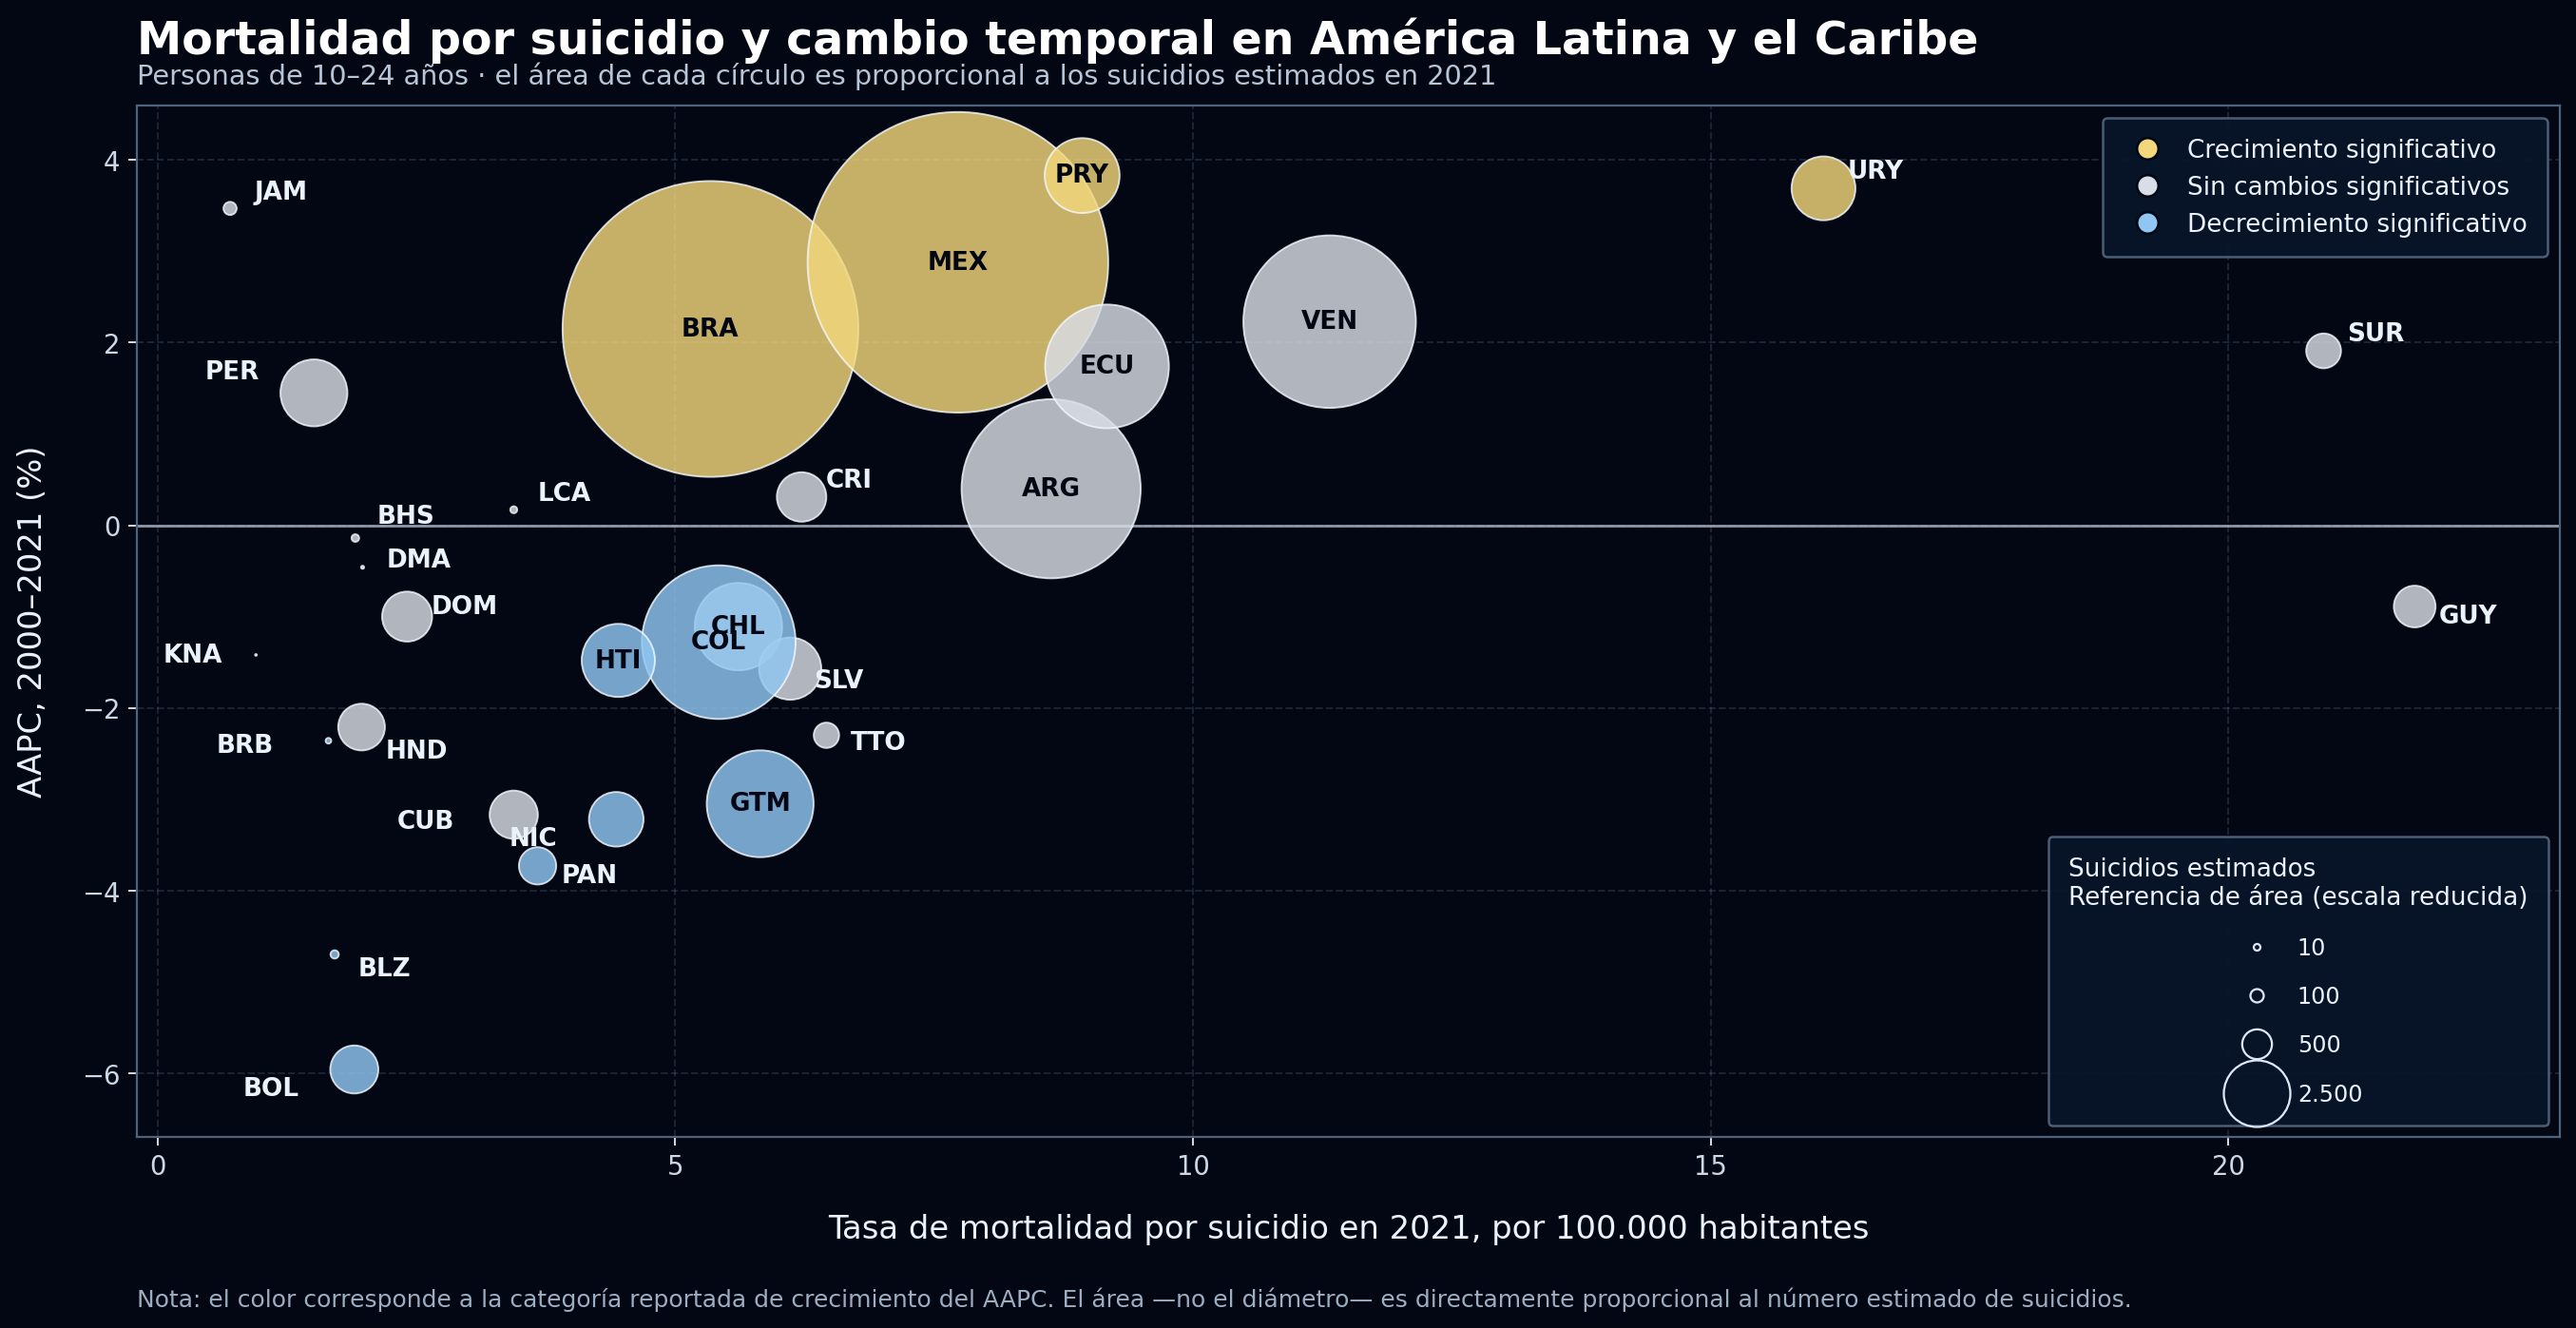

{'countries': 30,
 'coordinates_unchanged': True,
 'area_proportional_to_suicides': True}

In [12]:
rows_bub = load_rows(CSV)
make_chart(rows_bub, OUT)


verification_bubbles = {
    "countries": len(rows_bub),
    "coordinates_unchanged": True,
    "area_proportional_to_suicides": True,
}
verification_bubbles


## 6. Espirales de puntos — código integrado

Cada punto representa un suicidio estimado redondeado. La semilla pseudoaleatoria se deriva del ISO3, haciendo reproducible la geometría. Se verifican conteos, centros y ausencia de imágenes raster incrustadas en el SVG.


In [13]:
SVG_WIDTH = 2400
SVG_HEIGHT = 1400
PLOT_LEFT, PLOT_RIGHT = 205.0, 2260.0
PLOT_TOP, PLOT_BOTTOM = 180.0, 1160.0
X_MIN, X_MAX = 0.0, 23.0
Y_MIN, Y_MAX = -7.0, 5.0
POINT_RADIUS = 1.75
SPIRAL_RADIUS_FACTOR = 4.40
BACKGROUND = "#020713"
FOREGROUND = "#EAF2FA"
GRID = "#8294AD"
COLORS = {
    "crecimiento significativo": "#F2D77C",
    "sin cambios significativos": "#D9DDE5",
    "decrecimiento significativo": "#8FC7F2",
}


def round_half_up(value: float) -> int:
    return math.floor(value + 0.5)


def load_rows(path: Path) -> list[dict]:
    with path.open(encoding="utf-8-sig", newline="") as handle:
        reader = csv.DictReader(handle)
        rows = []
        for raw in reader:
            category = raw["Categoría de crecimiento"].strip().lower()
            if category not in COLORS:
                raise ValueError(f"Categoría no reconocida: {category}")
            estimate = float(raw["Suicidios estimados en 2021"])
            rows.append({
                "country": raw["País"].strip(),
                "iso": raw["Código ISO3"].strip(),
                "rate": float(raw["Tasa de mortalidad por suicidio en 2021 (por 100.000)"]),
                "aapc": float(raw["AAPC 2000–2021 (%)"]),
                "estimate": estimate,
                "count": round_half_up(estimate),
                "category": category,
            })
    return rows


def sx(value: float) -> float:
    return PLOT_LEFT + (value - X_MIN) / (X_MAX - X_MIN) * (PLOT_RIGHT - PLOT_LEFT)


def sy(value: float) -> float:
    return PLOT_BOTTOM - (value - Y_MIN) / (Y_MAX - Y_MIN) * (PLOT_BOTTOM - PLOT_TOP)


def galaxy_points(row: dict) -> tuple[np.ndarray, float, int]:
    """Genera una espiral determinista en coordenadas visuales del SVG."""
    n = row["count"]
    cx, cy = sx(row["rate"]), sy(row["aapc"])
    if n == 0:
        return np.empty((0, 2)), 0.0, 0
    rng = np.random.default_rng(zlib.crc32(row["iso"].encode("ascii")))
    radius = max(6.5, SPIRAL_RADIUS_FACTOR * math.sqrt(n))
    arms = 2 if n < 280 else 3 if n < 1200 else 4
    orientation = rng.uniform(0, 2 * math.pi)

    if n >= 1200:
        bulge_ratio, arm_ratio = 0.12, 0.56
    elif n >= 280:
        bulge_ratio, arm_ratio = 0.14, 0.51
    elif n >= 80:
        bulge_ratio, arm_ratio = 0.17, 0.44
    else:
        bulge_ratio, arm_ratio = 0.23, 0.26
    n_bulge = max(1, round(n * bulge_ratio))
    n_arms = round(n * arm_ratio)
    n_disk = n - n_bulge - n_arms
    points: list[tuple[float, float]] = []

    for _ in range(n_bulge):
        rr = min(abs(rng.normal(0, radius * 0.115)), radius * 0.34)
        theta = rng.uniform(0, 2 * math.pi)
        points.append((rr * math.cos(theta), rr * math.sin(theta)))

    arm_slots = [0] * arms
    for i in range(n_arms):
        arm = i % arms
        k = arm_slots[arm]
        arm_slots[arm] += 1
        total = math.ceil(n_arms / arms)
        q = (k + 0.65) / (total + 0.3)
        rr = radius * (0.11 + 0.89 * math.sqrt(q))
        qrad = rr / radius
        width = (0.11 if n >= 1200 else 0.15 if n >= 280 else 0.20) + 0.30 * qrad ** 1.25
        waviness = 0.065 * math.sin(9.5 * qrad + arm * 1.7)
        theta = (orientation + arm * 2 * math.pi / arms + 1.50 * math.pi * qrad
                 + waviness + rng.normal(0, width))
        rr += rng.normal(0, max(0.45, radius * (0.018 + 0.015 * qrad)))
        points.append((rr * math.cos(theta), rr * math.sin(theta)))

    for _ in range(n_disk):
        rr = radius * math.sqrt(rng.random())
        theta = rng.uniform(0, 2 * math.pi)
        points.append((rr * math.cos(theta), rr * math.sin(theta)))

    array = np.asarray(points, dtype=float)
    # Centro geométrico exacto antes de trasladar a las coordenadas tasa–AAPC.
    array -= array.mean(axis=0, keepdims=True)
    array[:, 0] += cx
    array[:, 1] += cy
    return array, radius, arms


def text_element(x: float, y: float, value: str, size: float, **attrs) -> str:
    properties = {"x": f"{x:.2f}", "y": f"{y:.2f}", "font-size": str(size), **attrs}
    parts = " ".join(f'{key.replace("_", "-")}="{html.escape(str(val))}"' for key, val in properties.items())
    return f"<text {parts}>{html.escape(value)}</text>"


def build_svg(rows: list[dict], output: Path) -> tuple[dict, Path]:
    computed = {}
    for row in rows:
        points, radius, arms = galaxy_points(row)
        computed[row["iso"]] = {"points": points, "radius": radius, "arms": arms}

    lines = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{SVG_WIDTH}" height="{SVG_HEIGHT}" viewBox="0 0 {SVG_WIDTH} {SVG_HEIGHT}">',
        '<title>Gráfico científico de espirales de puntos sobre mortalidad por suicidio</title>',
        f'<rect width="{SVG_WIDTH}" height="{SVG_HEIGHT}" fill="{BACKGROUND}"/>',
        '<g font-family="DejaVu Sans, Arial, sans-serif">',
    ]

    lines.append(text_element(PLOT_LEFT, 60,
        "Mortalidad por suicidio y cambio temporal en América Latina y el Caribe",
        42, fill="#FFFFFF", font_weight="700"))
    lines.append(text_element(PLOT_LEFT, 103,
        "Personas de 10–24 años · cada punto representa un suicidio estimado en 2021",
        22, fill="#B8C5D6"))

    for tick in [0, 5, 10, 15, 20]:
        x = sx(tick)
        lines.append(f'<line x1="{x:.2f}" y1="{PLOT_TOP}" x2="{x:.2f}" y2="{PLOT_BOTTOM}" stroke="{GRID}" stroke-opacity="0.20" stroke-dasharray="7 7"/>')
        lines.append(text_element(x, PLOT_BOTTOM + 38, str(tick), 20, fill="#CED8E5", text_anchor="middle"))
    for tick in [-6, -4, -2, 0, 2, 4]:
        y = sy(tick)
        lines.append(f'<line x1="{PLOT_LEFT}" y1="{y:.2f}" x2="{PLOT_RIGHT}" y2="{y:.2f}" stroke="{GRID}" stroke-opacity="0.20" stroke-dasharray="7 7"/>')
        lines.append(text_element(PLOT_LEFT - 20, y + 7, str(tick), 20, fill="#CED8E5", text_anchor="end"))
    zero_y = sy(0)
    lines.append(f'<line x1="{PLOT_LEFT}" y1="{zero_y:.2f}" x2="{PLOT_RIGHT}" y2="{zero_y:.2f}" stroke="#A8B6C8" stroke-opacity="0.85" stroke-width="1.8"/>')
    lines.append(f'<rect x="{PLOT_LEFT}" y="{PLOT_TOP}" width="{PLOT_RIGHT-PLOT_LEFT}" height="{PLOT_BOTTOM-PLOT_TOP}" fill="none" stroke="#50627A" stroke-width="1.5"/>')

    # Cada círculo siguiente es una observación individual, no decoración.
    lines.append('<g id="data-spirals" aria-label="Cada círculo representa un suicidio estimado">')
    for row in rows:
        points = computed[row["iso"]]["points"]
        color = COLORS[row["category"]]
        lines.append(
            f'<g id="{row["iso"]}" data-country="{html.escape(row["country"])}" '
            f'data-count="{row["count"]}" data-rate="{row["rate"]}" data-aapc="{row["aapc"]}" '
            f'data-category="{html.escape(row["category"])}" fill="{color}" fill-opacity="0.96">'
        )
        for x, y in points:
            lines.append(f'<circle cx="{x:.4f}" cy="{y:.4f}" r="{POINT_RADIUS}"/>')
        lines.append('</g>')
    lines.append('</g>')

    # Etiquetas exactamente sobre el centro del país, con halo oscuro legible.
    lines.append('<g id="country-labels" aria-label="Códigos ISO3">')
    for row in rows:
        lines.append(text_element(
            sx(row["rate"]), sy(row["aapc"]) + 7, row["iso"], 20,
            fill="#F5F8FC", text_anchor="middle", font_weight="700",
            stroke=BACKGROUND, stroke_width="5", paint_order="stroke fill",
        ))
    lines.append('</g>')

    lines.append(text_element((PLOT_LEFT + PLOT_RIGHT) / 2, 1255,
        "Tasa de mortalidad por suicidio en 2021, por 100.000 habitantes",
        25, fill=FOREGROUND, text_anchor="middle"))
    lines.append(text_element(55, (PLOT_TOP + PLOT_BOTTOM) / 2,
        "AAPC, 2000–2021 (%)", 25, fill=FOREGROUND, text_anchor="middle",
        transform=f"rotate(-90 55 {(PLOT_TOP + PLOT_BOTTOM) / 2:.2f})"))

    legend_x, legend_y = 1740, 198
    lines.append(f'<rect x="{legend_x}" y="{legend_y}" width="500" height="150" rx="8" fill="#08152A" fill-opacity="0.96" stroke="#50627A"/>')
    labels = [
        ("crecimiento significativo", "Crecimiento significativo"),
        ("sin cambios significativos", "Sin cambios significativos"),
        ("decrecimiento significativo", "Decrecimiento significativo"),
    ]
    for index, (key, label) in enumerate(labels):
        y = legend_y + 37 + index * 43
        lines.append(f'<circle cx="{legend_x+28}" cy="{y}" r="9" fill="{COLORS[key]}"/>')
        lines.append(text_element(legend_x + 52, y + 7, label, 20, fill=FOREGROUND))

    lines.append(text_element(PLOT_LEFT, 1335,
        "Nota: cada punto representa un suicidio estimado. El color indica la categoría reportada de crecimiento del AAPC.",
        19, fill="#9DAEC2"))
    lines += ['</g>', '</svg>']
    svg_text = "\n".join(lines)

    # Mostrar directamente el SVG construido en memoria.
    # No se vuelve a leer desde el archivo para visualizarlo.
    display(SVG(data=svg_text))

    output.write_text(svg_text, encoding="utf-8")
    return computed, output


def render_png(svg: Path, png: Path) -> None:
    subprocess.run([
        "inkscape", str(svg), f"--export-filename={png}",
        "--export-width=2400", "--export-height=1400",
    ], check=True)


def validate(rows: list[dict], computed: dict, svg: Path, output: Path) -> None:
    per_country = {}
    max_error = 0.0
    for row in rows:
        points = computed[row["iso"]]["points"]
        if len(points):
            mean = points.mean(axis=0)
            error = math.hypot(mean[0] - sx(row["rate"]), mean[1] - sy(row["aapc"]))
        else:
            error = 0.0
        max_error = max(max_error, error)
        per_country[row["iso"]] = {
            "points": len(points), "expected": row["count"],
            "center_error_svg_units": error,
        }
    text = svg.read_text(encoding="utf-8")
    report = {
        "countries": len(rows),
        "total_points": sum(row["count"] for row in rows),
        "category_counts": dict(Counter(row["category"] for row in rows)),
        "point_radius_svg_units": POINT_RADIUS,
        "canvas": [SVG_WIDTH, SVG_HEIGHT],
        "spiral_radius_factor": SPIRAL_RADIUS_FACTOR,
        "per_country": per_country,
        "checks": {
            "counts_exact": all(v["points"] == v["expected"] for v in per_country.values()),
            "centers_exact_below_1e-9": max_error < 1e-9,
            "no_raster_images_inside_svg": "<image" not in text,
            "svg_circle_count": text.count("<circle "),
        },
    }
    output.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")


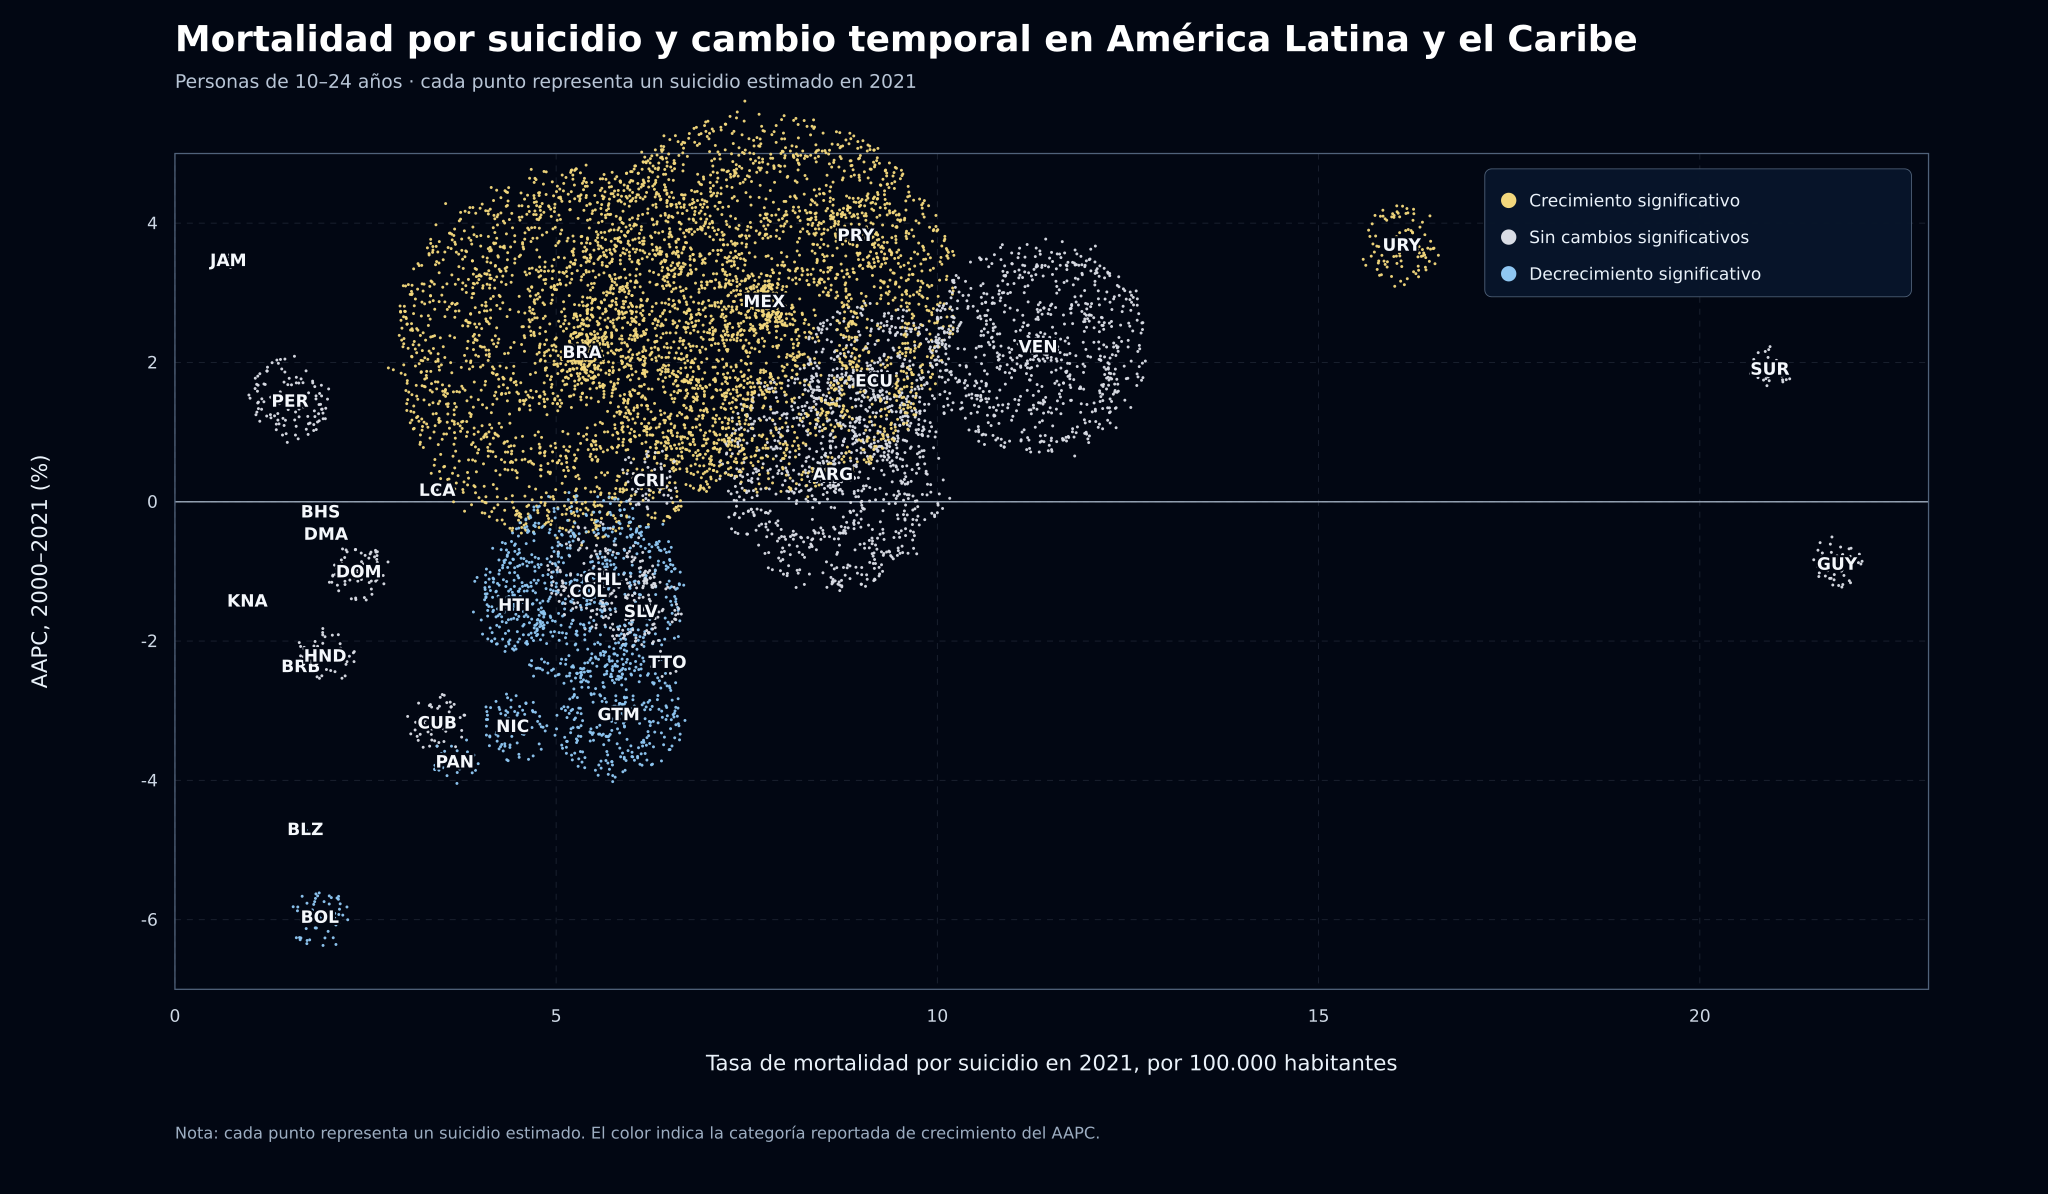

Inkscape no disponible: el SVG se genera y se muestra correctamente; solo se omite el PNG.


{'counts_exact': True,
 'centers_exact_below_1e-9': True,
 'no_raster_images_inside_svg': True,
 'svg_circle_count': 9731}

In [14]:
rows_spiral = load_rows(CSV)
svg = OUT / "espirales_cientifica_fondo_negro.svg"
png = OUT / "espirales_cientifica_fondo_negro.png"
report = OUT / "verificacion_espirales.json"

computed, _ = build_svg(rows_spiral, svg)
validate(rows_spiral, computed, svg, report)


# El SVG ya se mostró directamente al crearse. El PNG es opcional para descarga.
if shutil.which("inkscape"):
    render_png(svg, png)
else:
    print("Inkscape no disponible: el SVG se genera y se muestra correctamente; solo se omite el PNG.")

spiral_report = json.loads(report.read_text(encoding="utf-8"))
spiral_report["checks"]


## 7. Verificación cruzada


In [15]:
coords=df[['Código ISO3','Tasa de mortalidad por suicidio en 2021 (por 100.000)','AAPC 2000–2021 (%)']].sort_values('Código ISO3')
assert verification_dispersion['coordinates_unchanged']
assert verification_bubbles['coordinates_unchanged']
assert spiral_report['checks']['counts_exact']
assert spiral_report['checks']['centers_exact_below_1e-9']
print('Verificación cruzada: OK')
coords.head(10)


Verificación cruzada: OK


,Código ISO3,Tasa de mortalidad por suicidio en 2021 (por 100.000),AAPC 2000–2021 (%)
0,ARG,8.63,0.40
1,BHS,1.91,-0.14
3,BLZ,1.71,-4.70
4,BOL,1.90,-5.96
5,BRA,5.34,2.15
2,BRB,1.65,-2.36
6,CHL,5.61,-1.11
7,COL,5.42,-1.28
8,CRI,6.22,0.31
9,CUB,3.44,-3.17


## 8. Salidas y alcance

Las salidas se guardan en `outputs/`. El notebook documenta la fase computacional reproducible. La digitalización del dibujo y la composición artística final son transformaciones visuales asistidas por IA y supervisadas humanamente; no forman parte de las transformaciones numéricas ejecutadas aquí.
